# ML Week 18: Segmentation

Alongside Object Detection with YOLO, the idea of "Segmenting" an image into different parts, each corresponding to an object, was a very hot idea.

To do Image Segmentation "decently" well turned out to be about as difficult as Object Detection, and was accomplished around 2015 by an architecture called U-Net.

However to do Image Segmentation very well is harder than Object Detection. This involves really knowing whether or not a pixel belongs to one object or another.

Image Segmentation has only JUST reached maturity with the help of very clever transformer models.

Today will we use the current state-of-the-art semgnetaion model: Facebooks's SAM 3 (Segment Anything Model 3). It was realeased in November 2025.

Source: https://docs.ultralytics.com/models/sam-3#concept-segmentation-examples

SAM3 consists of:

* A "Perception Encoder" which turns an image into many embedding vectors represeting all the strucutre/colours/shapes etc. in the image.

* A "Text Encoder" which takes a prompt and turns in into an embedding vectors representing what is sought after

* A "Detector" which takes in a fusion of both encoddings and outputs where it has been found. For SAM3 the Detector is based on DETR.

### Simplest Example

Let's build a basic example by segmenting an image with Pikachu.

**Note**: becuase the SAM3 model is so recent it is somewhat "guarded". Ultralytics (which we used last week) does not include it. It is available on Hugging Face, but you can't simply download it. You have to request it and be approved by the dev team.

You have to download it (which may take some time) and then put it into the same folder as this notebook. Then we can get started.

In [6]:
from ultralytics.models.sam import SAM3SemanticPredictor

# Initialize predictor with configuration
overrides = dict(
    conf=0.25,  # Confidence threshold
    task="segment",
    mode="predict",
    model="sam3.pt",
    half=False,  # FP16 precision, "True" requires GPU
    save=True,
)
predictor = SAM3SemanticPredictor(overrides=overrides)

# Set image to be used (can be used with multiple queries)
predictor.set_image("pikachu.jpg")

# Query with text prompt
results = predictor(text=["Pikachu"])

Ultralytics 8.4.53  Python-3.13.5 torch-2.7.0+cu126 CUDA:0 (NVIDIA RTX 2000 Ada Generation Laptop GPU, 8188MiB)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 c:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\pikachu.jpg: 644x644 1 Pikachu, 192.3ms
Speed: 2.3ms preprocess, 192.3ms inference, 8.3ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\runs\segment\predict-10


In [176]:
# Let's see the segmentation

results[0].show()

### Segmenting with multiple classes

In [5]:
results = predictor(text=["Pikachu", "Grass", "Tail"])

results[0].show()


image 1/1 c:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\pikachu.jpg: 644x644 1 Pikachu, 12 Grasss, 1 Tail, 3103.4ms
Speed: 4.8ms preprocess, 3103.4ms inference, 1.5ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\runs\segment\predict-8


### Cropping out the segmented region for further processing

We can also remove everything from the photo except the object we plan on studying further. Here is a function to do that.

Note: This could be more complicated if you have multiple classes, or instances of the same class (ie two Pikachu's in one photo). In such a case you would need to choose the corresponding mask from the results.

In [25]:
results[0].masks.data.cpu().numpy()

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]],
      shape=(1, 192, 342))

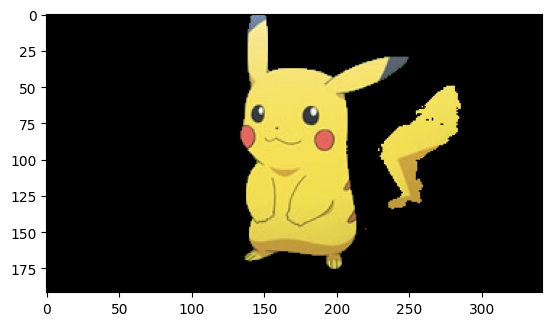

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("pikachu.jpg")

def crop_from_mask(img, results):
    mask = results[0].masks.data.cpu().numpy()[0,:,:]  # Take the mask from the results data
    cropped_img = img * mask[..., np.newaxis]  # Apply the mask to the image
    plt.imshow(cropped_img)
    plt.show()
    return cropped_img

cropped_img = crop_from_mask(img, results)


# Exercises

### Exercise 1

The huge weights file of SAM3 contains a lot of learned knowledge about human culture (even what a Pikachu is!). But it is not infinite! We may certainly run into instances in which we need more nuanced classes. Let's see an example.

### Exercise 1.1

Let's use Pikachu and Pichu again, two classes that are very similar but with subtle differences (Pichu has a black tail, larger ears, black patterns around the neck, etc.).

Could it be that the SAM3 weights also encode the concept of a Pichu? Let's test this by asking SAM3 to segment Pichu in the photo "pikachu_and_pichu.png".

In [187]:
predictor.set_image("pikachu_and_pichu.png")
results = predictor(text=["Pichu"])

results[0].show()

WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 c:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\pikachu_and_pichu.png: 644x644 (no detections), 541.0ms
Speed: 3.2ms preprocess, 541.0ms inference, 0.4ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\runs\segment\predict-6


### Exercise 1.2

Well, it unfortunately doesn't seem like SAM3 knows what a "Pichu" is (Pikachu is a general enough concept to have found its way into the SAM3 training data*, Pichu on the other hand is simply too specific)

What would happen if we just searched for "Pikachu" in the image? Let's try this.

\* *Note*: To be more technical, Pichu wasn't in the data used to train the "Text Encoder" segment of the SAM3 pipeline.

In [188]:
predictor.set_image("pikachu_and_pichu.png")
results = predictor(text=["Pikachu"])

results[0].show()

WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 c:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\pikachu_and_pichu.png: 644x644 3 Pikachus, 647.7ms
Speed: 3.7ms preprocess, 647.7ms inference, 6.6ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\runs\segment\predict-6


### Exercise 1.3

Unsurprisingly SAM3 thinks that the Pichu are also Pikachus. How can we teach it the difference?

As we saw in the last 2 weeks, for Image Classification and Object Detection the solution is Transfer Learning.

However, for this latest generation of Image Segmentation, there is a very interesting new way of approaching the problem.

Beacuse the powerful Text Embedder already has so much understanding of many common objects in our world we can *explain* what a Pichu is!

Using the same image, hand the text argument as:
text=["pikachu", "pichu"]
except replace these words with descriptions of the two classes. Think about what makes them unique, and then write this in the string (the text encoder is not limited to single words for classes - it can also take longer strings)

In [190]:
predictor.set_image("pikachu_and_pichu.png")
results = predictor(text=["large yellow mouse with a yellow tail", "small yellow mouse with a black tail"])

results[0].show()

WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 c:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\pikachu_and_pichu.png: 644x644 3 large yellow mouse with a yellow tails, 3 small yellow mouse with a black tails, 1161.1ms
Speed: 2.9ms preprocess, 1161.1ms inference, 7.8ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\runs\segment\predict-6


### Exercise 2

For Sementation, as well as the previous ML techniques we have learned, we may want to quickly parse through many photos and apply the same model to all of them.

Let's build a quick example of this here.

Create a subfolder in this folder called "images" and put some images in there. Then use the code below to loop over them and repeatedly apply SAM3.

In [ ]:
import os

filepath = "./images/"

files = os.listdir(filepath)
for filename in files:
    if filename.split(".")[-1] in ["png", "jpg", "JPEG"]:
        predictor.set_image(filepath + filename)
        results = predictor(text=["Pikachu"])

        results[0].show()

WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 c:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\pikachu.jpg: 644x644 1 Pikachu, 552.4ms
Speed: 2.4ms preprocess, 552.4ms inference, 0.8ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\runs\segment\predict-6
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 c:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\pikachu_and_pichu.png: 644x644 3 Pikachus, 566.0ms
Speed: 2.7ms preprocess, 566.0ms inference, 4.0ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\runs\segment\predict-6
